# Personal Finance Health Predictor - Customer Segmentation

This notebook performs customer segmentation using clustering algorithms.

# Setup & Imports

In [9]:
# Setup: Set working directory to project root
import os
import sys
from pathlib import Path

# Get the project root directory (parent of notebooks folder)
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
    os.chdir(project_root)
    print(f"✓ Working directory set to: {os.getcwd()}")
elif (notebook_dir / 'notebooks').exists():
    project_root = notebook_dir
    print(f"✓ Working directory: {os.getcwd()}")
else:
    current = notebook_dir
    while current != current.parent:
        if (current / 'data').exists() or (current / 'notebooks').exists():
            project_root = current
            os.chdir(project_root)
            print(f"✓ Working directory set to: {os.getcwd()}")
            break
        current = current.parent
    else:
        print(f"⚠ Warning: Could not find project root. Current directory: {os.getcwd()}")

✓ Working directory: c:\Users\manas\Desktop\Projects\personal-finance-health-predictor


In [10]:
# Verify working directory
print(f"Current working directory: {os.getcwd()}")
print(f"Data directory exists: {os.path.exists('data/processed')}")
print(f"Models directory exists: {os.path.exists('models')}")

Current working directory: c:\Users\manas\Desktop\Projects\personal-finance-health-predictor
Data directory exists: True
Models directory exists: True


In [11]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# File management
import joblib

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Load German Credit Data

In [12]:
# Load the processed/scaled data
df = pd.read_csv('data/processed/german_credit_final.csv')
print(f"\n✅ Loaded: german_credit_final.csv")

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

# Data info
print("\n📊 Dataset Info:")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   Data types:\n{df.dtypes.value_counts()}")

# Store original features
print(f"\n📋 Features ({len(df.columns)}):")
print(f"   {', '.join(df.columns[:10].tolist())}...")


✅ Loaded: german_credit_final.csv

📊 Dataset Shape: (1000, 33)
   Rows: 1,000
   Columns: 33

📊 Dataset Info:
   Memory usage: 0.25 MB
   Data types:
int64      28
float64     5
Name: count, dtype: int64

📋 Features (33):
   Age, Job, Credit amount, Duration, monthly_payment, high_value_loan, age_to_duration_ratio, Sex_encoded, Housing_own, Housing_rent...


# Load Scaled Data & Verify

In [13]:
# Data is already scaled from Day 2 preprocessing!
print("\n✅ German Credit data was scaled in Day 2:")
print("   → Continuous features scaled with StandardScaler")
print("   → Binary/one-hot features kept as-is")
print("   → Ordinal features (Job) kept as-is")

# Use the data we already loaded
X_scaled = df.copy()

print(f"\n📊 Clustering dataset ready!")
print(f"   Rows: {X_scaled.shape[0]:,}")
print(f"   Features: {X_scaled.shape[1]}")

# Verify scaling
numeric_cols = X_scaled.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n🔍 Verifying scaled features:")

# Check a few continuous features (should have mean ≈ 0, std ≈ 1)
sample_cols = [col for col in numeric_cols if X_scaled[col].nunique() > 2][:3]
print("\n   Sample continuous features:")
for col in sample_cols:
    mean = X_scaled[col].mean()
    std = X_scaled[col].std()
    print(f"   • {col:30s} Mean: {mean:7.3f}, Std: {std:7.3f}")

print("\n✅ Data is ready for clustering!")
print(f"   Total features: {len(numeric_cols)}")


✅ German Credit data was scaled in Day 2:
   → Continuous features scaled with StandardScaler
   → Binary/one-hot features kept as-is
   → Ordinal features (Job) kept as-is

📊 Clustering dataset ready!
   Rows: 1,000
   Features: 33

🔍 Verifying scaled features:

   Sample continuous features:
   • Age                            Mean:   0.000, Std:   1.001
   • Job                            Mean:   1.904, Std:   0.654
   • Credit amount                  Mean:   0.000, Std:   1.001

✅ Data is ready for clustering!
   Total features: 33


# Optimal Number of Clusters Analysis

In [14]:
print("\n🎯 Methods:")
print("   1. Elbow Method (Inertia)")
print("   2. Silhouette Score")
print("   3. Davies-Bouldin Index")
print("   4. Calinski-Harabasz Score")

# Test K values from 2 to 10
k_range = range(2, 11)

# Storage for metrics
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_scores = []

print("\n⚙️  Testing K-Means for K = 2 to 10...")
print("\nK  | Inertia  | Silhouette | Davies-Bouldin | Calinski-Harabasz")
print("-" * 75)

for k in k_range:
    # Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)

    # Calculate metrics
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)

    # Store results
    inertias.append(inertia)
    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)
    calinski_scores.append(calinski)

    print(f"{k:2d} | {inertia:8.0f} | {silhouette:10.4f} | {davies_bouldin:14.4f} | {calinski:17.2f}")

print("\n✅ Analysis complete!")

# Find optimal K for each metric
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
optimal_k_davies = k_range[np.argmin(davies_bouldin_scores)]
optimal_k_calinski = k_range[np.argmax(calinski_scores)]

print("\n📊 Optimal K by metric:")
print(f"   • Silhouette Score (highest): K = {optimal_k_silhouette}")
print(f"   • Davies-Bouldin (lowest): K = {optimal_k_davies}")
print(f"   • Calinski-Harabasz (highest): K = {optimal_k_calinski}")


🎯 Methods:
   1. Elbow Method (Inertia)
   2. Silhouette Score
   3. Davies-Bouldin Index
   4. Calinski-Harabasz Score

⚙️  Testing K-Means for K = 2 to 10...

K  | Inertia  | Silhouette | Davies-Bouldin | Calinski-Harabasz
---------------------------------------------------------------------------
 2 |     7547 |     0.2410 |         1.7818 |            213.19
 3 |     6536 |     0.1853 |         1.8342 |            200.12
 4 |     6096 |     0.1380 |         1.9870 |            166.89
 5 |     5713 |     0.1479 |         1.8021 |            150.06
 6 |     5331 |     0.1205 |         1.7456 |            142.78
 7 |     5050 |     0.1262 |         1.8235 |            134.67
 8 |     4848 |     0.1175 |         1.7856 |            126.06
 9 |     4590 |     0.1363 |         1.7534 |            123.30
10 |     4426 |     0.1261 |         1.7778 |            117.63

✅ Analysis complete!

📊 Optimal K by metric:
   • Silhouette Score (highest): K = 2
   • Davies-Bouldin (lowest): K = 6
 

Visualize Optimal K Analysis

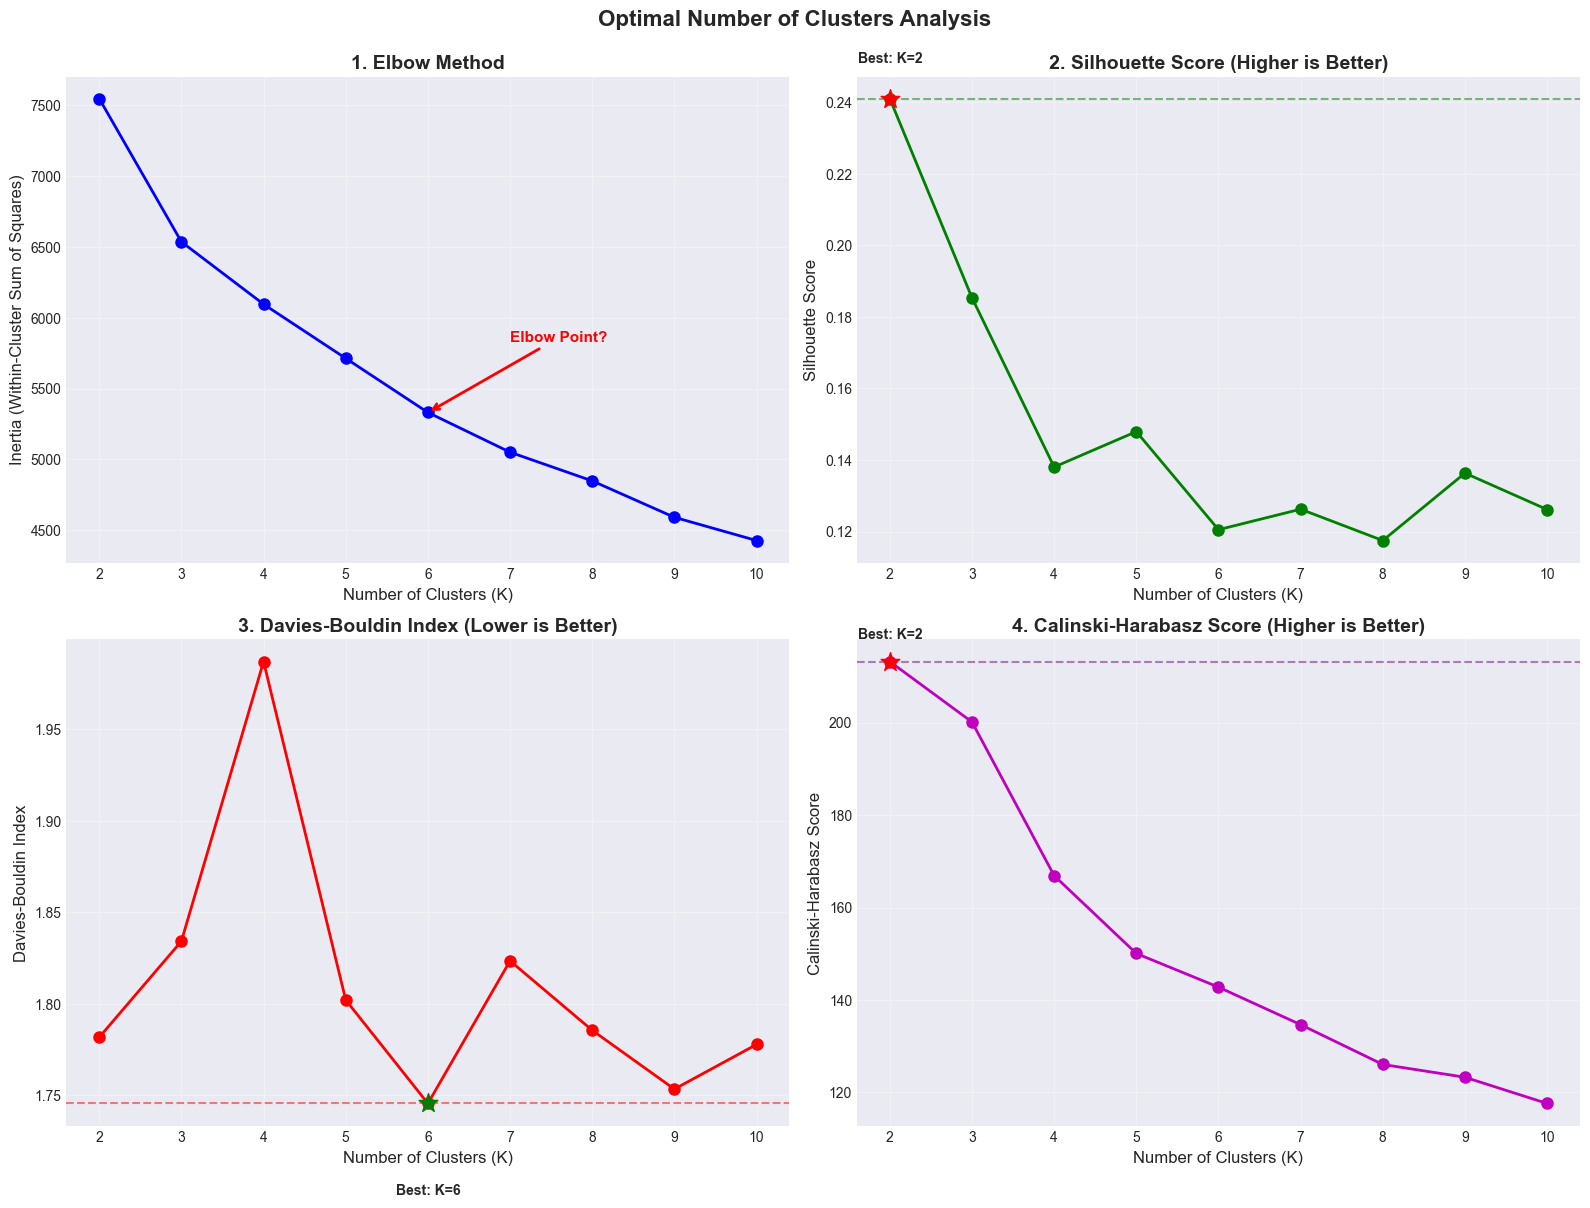


📊 RECOMMENDATION

🎯 Based on the metrics:
   • Silhouette Score suggests: K = 2
   • Davies-Bouldin suggests: K = 6
   • Calinski-Harabasz suggests: K = 2


In [15]:
# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Optimal Number of Clusters Analysis', fontsize=16, fontweight='bold', y=0.995)

# 1. Elbow Method (Inertia)
ax1 = axes[0, 0]
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('1. Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

# Add elbow annotation
elbow_k = 6  # Visual inspection suggests elbow around K=6
ax1.annotate('Elbow Point?', xy=(elbow_k, inertias[elbow_k-2]),
             xytext=(elbow_k+1, inertias[elbow_k-2]+500),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, color='red', fontweight='bold')

# 2. Silhouette Score
ax2 = axes[0, 1]
ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('2. Silhouette Score (Higher is Better)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_range)
ax2.axhline(y=max(silhouette_scores), color='green', linestyle='--', alpha=0.5)

# Highlight best K
best_k_sil = optimal_k_silhouette
ax2.scatter([best_k_sil], [silhouette_scores[best_k_sil-2]],
            color='red', s=200, zorder=5, marker='*')
ax2.text(best_k_sil, silhouette_scores[best_k_sil-2]+0.01,
         f'Best: K={best_k_sil}', ha='center', fontsize=10, fontweight='bold')

# 3. Davies-Bouldin Index
ax3 = axes[1, 0]
ax3.plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
ax3.set_xlabel('Number of Clusters (K)', fontsize=12)
ax3.set_ylabel('Davies-Bouldin Index', fontsize=12)
ax3.set_title('3. Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xticks(k_range)
ax3.axhline(y=min(davies_bouldin_scores), color='red', linestyle='--', alpha=0.5)

# Highlight best K
best_k_db = optimal_k_davies
ax3.scatter([best_k_db], [davies_bouldin_scores[best_k_db-2]],
            color='green', s=200, zorder=5, marker='*')
ax3.text(best_k_db, davies_bouldin_scores[best_k_db-2]-0.05,
         f'Best: K={best_k_db}', ha='center', fontsize=10, fontweight='bold')

# 4. Calinski-Harabasz Score
ax4 = axes[1, 1]
ax4.plot(k_range, calinski_scores, 'mo-', linewidth=2, markersize=8)
ax4.set_xlabel('Number of Clusters (K)', fontsize=12)
ax4.set_ylabel('Calinski-Harabasz Score', fontsize=12)
ax4.set_title('4. Calinski-Harabasz Score (Higher is Better)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_xticks(k_range)
ax4.axhline(y=max(calinski_scores), color='purple', linestyle='--', alpha=0.5)

# Highlight best K
best_k_ch = optimal_k_calinski
ax4.scatter([best_k_ch], [calinski_scores[best_k_ch-2]],
            color='red', s=200, zorder=5, marker='*')
ax4.text(best_k_ch, calinski_scores[best_k_ch-2]+5,
         f'Best: K={best_k_ch}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()

# Create the directory if it doesn't exist
import os
os.makedirs('results/clustering', exist_ok=True)

plt.savefig('results/clustering/day7_01_optimal_k_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Recommendation
print("\n" + "="*70)
print("📊 RECOMMENDATION")
print("="*70)
print("\n🎯 Based on the metrics:")
print(f"   • Silhouette Score suggests: K = {optimal_k_silhouette}")
print(f"   • Davies-Bouldin suggests: K = {optimal_k_davies}")
print(f"   • Calinski-Harabasz suggests: K = {optimal_k_calinski}")

# K-Means Clustering (Multiple K Values)

In [16]:
# Store models and results
kmeans_models = {}
cluster_results = {}

# Create models directory
os.makedirs('models/clustering', exist_ok=True)

k_values = [2, 4, 5, 6]

for k in k_values:
    print(f"\n{'='*70}")
    print(f"K-MEANS WITH K = {k}")
    print(f"{'='*70}")

    # Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)

    # Calculate metrics
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)
    inertia = kmeans.inertia_

    # Store model
    kmeans_models[f'kmeans_k{k}'] = kmeans

    # Store results
    cluster_results[k] = {
        'labels': labels,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski': calinski,
        'inertia': inertia
    }

    # Cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    cluster_sizes = dict(zip(unique, counts))

    print(f"\n📊 Performance Metrics:")
    print(f"   • Silhouette Score: {silhouette:.4f}")
    print(f"   • Davies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"   • Calinski-Harabasz Score: {calinski:.2f}")
    print(f"   • Inertia: {inertia:.2f}")

    print(f"\n👥 Cluster Distribution:")
    for cluster_id, size in cluster_sizes.items():
        percentage = (size / len(labels)) * 100
        print(f"   Cluster {cluster_id}: {size:4d} customers ({percentage:5.1f}%)")

    # Save model
    joblib.dump(kmeans, f'models/clustering/kmeans_k{k}.pkl')

print("\n" + "="*70)
print("✅ ALL K-MEANS MODELS COMPLETE!")
print("="*70)


K-MEANS WITH K = 2

📊 Performance Metrics:
   • Silhouette Score: 0.2410
   • Davies-Bouldin Index: 1.7818
   • Calinski-Harabasz Score: 213.19
   • Inertia: 7547.41

👥 Cluster Distribution:
   Cluster 0:  229 customers ( 22.9%)
   Cluster 1:  771 customers ( 77.1%)

K-MEANS WITH K = 4

📊 Performance Metrics:
   • Silhouette Score: 0.1380
   • Davies-Bouldin Index: 1.9870
   • Calinski-Harabasz Score: 166.89
   • Inertia: 6095.53

👥 Cluster Distribution:
   Cluster 0:  132 customers ( 13.2%)
   Cluster 1:  226 customers ( 22.6%)
   Cluster 2:  189 customers ( 18.9%)
   Cluster 3:  453 customers ( 45.3%)

K-MEANS WITH K = 5

📊 Performance Metrics:
   • Silhouette Score: 0.1479
   • Davies-Bouldin Index: 1.8021
   • Calinski-Harabasz Score: 150.06
   • Inertia: 5713.12

👥 Cluster Distribution:
   Cluster 0:   18 customers (  1.8%)
   Cluster 1:  174 customers ( 17.4%)
   Cluster 2:  182 customers ( 18.2%)
   Cluster 3:  195 customers ( 19.5%)
   Cluster 4:  431 customers ( 43.1%)

K-MEA

Summary comparison

In [17]:
print("\n📊 MODEL COMPARISON SUMMARY:\n")
print("K  | Silhouette | Davies-Bouldin | Calinski-Harabasz | Inertia")
print("-" * 75)
for k in k_values:
    results = cluster_results[k]
    print(f"{k}  | {results['silhouette']:10.4f} | {results['davies_bouldin']:14.4f} | "
          f"{results['calinski']:17.2f} | {results['inertia']:8.0f}")


📊 MODEL COMPARISON SUMMARY:

K  | Silhouette | Davies-Bouldin | Calinski-Harabasz | Inertia
---------------------------------------------------------------------------
2  |     0.2410 |         1.7818 |            213.19 |     7547
4  |     0.1380 |         1.9870 |            166.89 |     6096
5  |     0.1479 |         1.8021 |            150.06 |     5713
6  |     0.1205 |         1.7456 |            142.78 |     5331


# Dimensionality Reduction & Visualization

Applying dimensionality reduction for visualization

In [19]:
# PCA (2 components)
print("\n1️⃣  PCA (2 components)...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"   ✅ Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# t-SNE (2 components) - takes a bit longer
print("\n2️⃣  t-SNE (2 components)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print(f"   ✅ t-SNE complete!")

# Save dimensionality reduction models
joblib.dump(pca, 'models/clustering/pca_2d.pkl')

print("\n✅ Dimensionality reduction complete!")


1️⃣  PCA (2 components)...
   ✅ Explained variance: 45.21%

2️⃣  t-SNE (2 components)...
   ✅ t-SNE complete!

✅ Dimensionality reduction complete!


Visualization

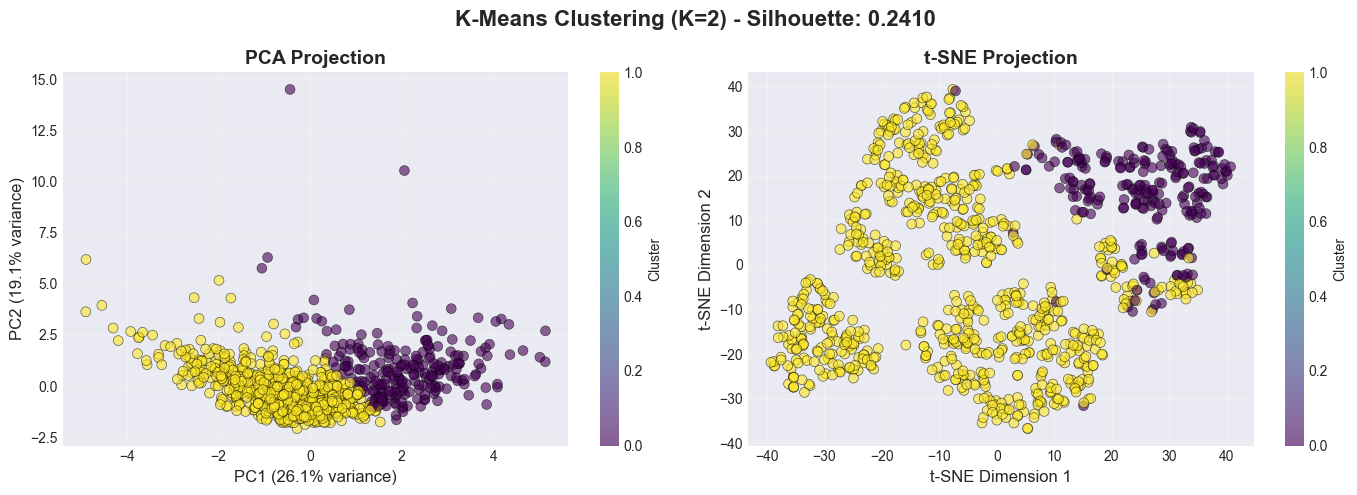

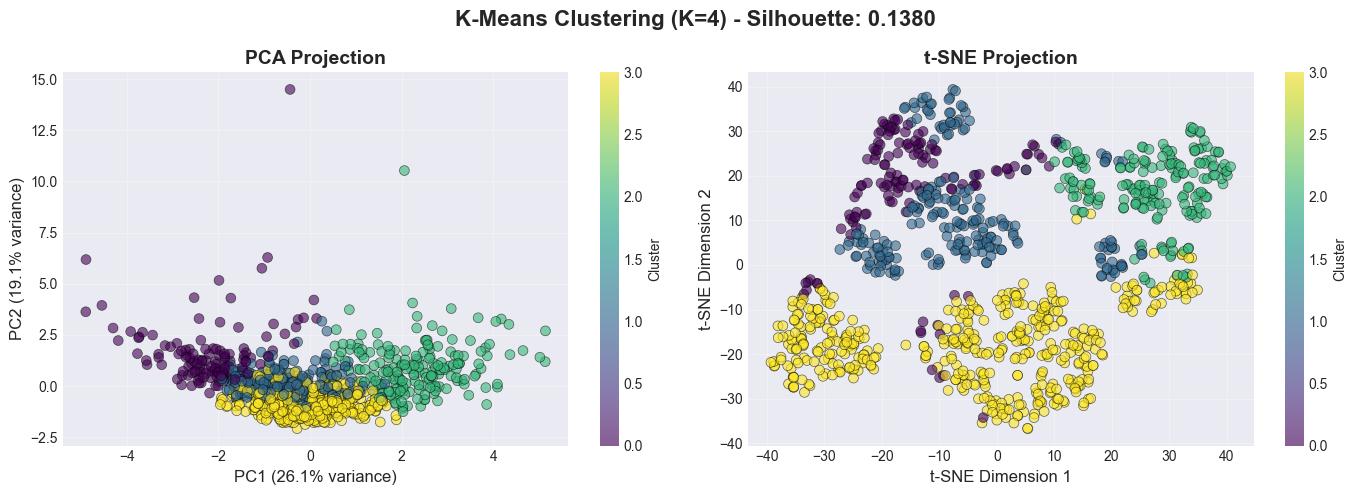

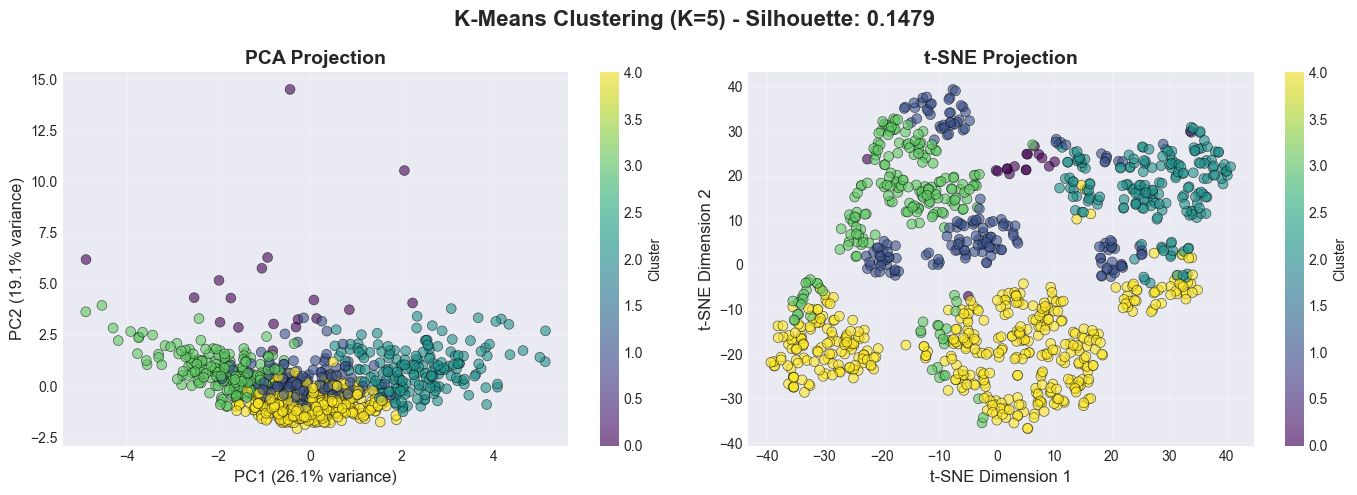

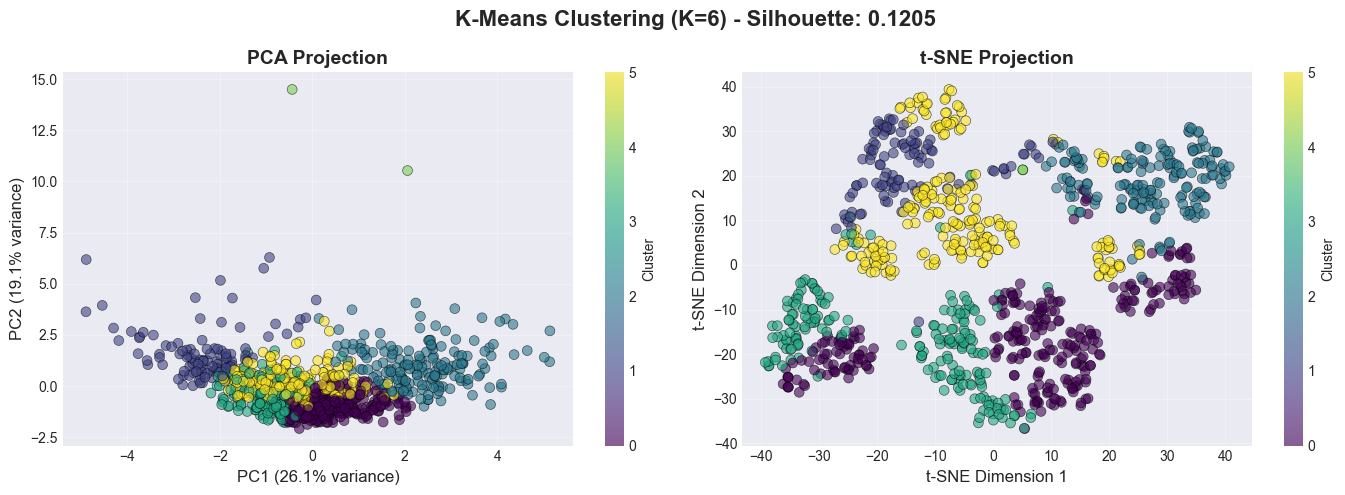

In [20]:
# Create visualization for each K value
k_values = [2, 4, 5, 6]

for k in k_values:
    labels = cluster_results[k]['labels']

    # Create 1x2 subplot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'K-Means Clustering (K={k}) - Silhouette: {cluster_results[k]["silhouette"]:.4f}',
                 fontsize=16, fontweight='bold')

    # PCA visualization
    ax1 = axes[0]
    scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis',
                          alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    ax1.set_title('PCA Projection', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=ax1, label='Cluster')

    # t-SNE visualization
    ax2 = axes[1]
    scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis',
                          alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    ax2.set_xlabel('t-SNE Dimension 1', fontsize=12)
    ax2.set_ylabel('t-SNE Dimension 2', fontsize=12)
    ax2.set_title('t-SNE Projection', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=ax2, label='Cluster')

    plt.tight_layout()
    plt.show()

# Cluster Labels & Profile Analysis

Cluster Labeling

In [21]:
# Based on our metrics, let's choose K=4 as a good balance
# (K=2 too simple, K=6 too granular, K=4 or K=5 is a sweet spot)

CHOSEN_K = 4  # You can change this to 5 or 6 if you prefer

print(f"\n🎯 Selected K = {CHOSEN_K} for detailed profiling")
print(f"\n📊 Performance:")
print(f"   • Silhouette Score: {cluster_results[CHOSEN_K]['silhouette']:.4f}")
print(f"   • Davies-Bouldin Index: {cluster_results[CHOSEN_K]['davies_bouldin']:.4f}")
print(f"   • Calinski-Harabasz Score: {cluster_results[CHOSEN_K]['calinski']:.2f}")

# Add cluster labels to original dataframe
df['Cluster'] = cluster_results[CHOSEN_K]['labels']
df['Cluster_PCA1'] = X_pca[:, 0]
df['Cluster_PCA2'] = X_pca[:, 1]
df['Cluster_tSNE1'] = X_tsne[:, 0]
df['Cluster_tSNE2'] = X_tsne[:, 1]

print(f"\n✅ Added cluster labels to dataframe!")
print(f"   New columns: Cluster, Cluster_PCA1, Cluster_PCA2, Cluster_tSNE1, Cluster_tSNE2")

# Cluster size distribution
print(f"\n👥 Cluster Distribution (K={CHOSEN_K}):")
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   Cluster {cluster_id}: {count:4d} customers ({percentage:5.1f}%)")


🎯 Selected K = 4 for detailed profiling

📊 Performance:
   • Silhouette Score: 0.1380
   • Davies-Bouldin Index: 1.9870
   • Calinski-Harabasz Score: 166.89

✅ Added cluster labels to dataframe!
   New columns: Cluster, Cluster_PCA1, Cluster_PCA2, Cluster_tSNE1, Cluster_tSNE2

👥 Cluster Distribution (K=4):
   Cluster 0:  132 customers ( 13.2%)
   Cluster 1:  226 customers ( 22.6%)
   Cluster 2:  189 customers ( 18.9%)
   Cluster 3:  453 customers ( 45.3%)


Profile Analysis

In [22]:
# Get original (unscaled) feature names for profiling
# We need to identify which features were scaled
original_features = X_scaled.columns.tolist()

print(f"\n📋 Features available for profiling: {len(original_features)}")

# Create cluster profiles by calculating mean of each feature per cluster
print(f"\n⚙️  Calculating cluster profiles...")

cluster_profiles = df.groupby('Cluster')[original_features].mean()

print(f"\n✅ Cluster profiles created!")
print(f"   Shape: {cluster_profiles.shape}")

# Display top features that differentiate clusters
print(f"\n📊 Cluster Profiles Preview (first 10 features):\n")
print(cluster_profiles.iloc[:, :10].round(3))

# Save cluster profiles
cluster_profiles.to_csv('results/clustering/day7_cluster_profiles.csv')

# Save dataframe with cluster labels
df.to_csv('data/processed/german_credit_with_clusters.csv', index=False)


📋 Features available for profiling: 33

⚙️  Calculating cluster profiles...

✅ Cluster profiles created!
   Shape: (4, 33)

📊 Cluster Profiles Preview (first 10 features):

           Age    Job  Credit amount  Duration  monthly_payment  \
Cluster                                                           
0        1.126  1.727         -0.413    -1.031            0.648   
1        0.816  1.867         -0.327    -0.009           -0.313   
2       -0.083  2.222          1.647     1.330            0.531   
3       -0.700  1.841         -0.404    -0.250           -0.254   

         high_value_loan  age_to_duration_ratio  Sex_encoded  Housing_own  \
Cluster                                                                     
0                  0.106                  2.013        0.720        0.705   
1                  0.097                  0.017        0.805        0.779   
2                  0.979                 -0.720        0.767        0.619   
3                  0.064              

Detailed Cluster Profiling & Interpretation


⚙️  Identifying most important features for segmentation...

CLUSTER PROFILES - TOP DIFFERENTIATING FEATURES

Cluster Comparison (Top 10 Features):

Cluster                            0      1      2      3
age_to_duration_ratio          2.013  0.017 -0.720 -0.295
Credit amount                 -0.413 -0.327  1.647 -0.404
Duration                      -1.031 -0.009  1.330 -0.250
Age                            1.126  0.816 -0.083 -0.700
monthly_payment                0.648 -0.313  0.531 -0.254
high_value_loan                0.106  0.097  0.979  0.064
age_group_Mature               0.424  0.819  0.307  0.000
credit_category_Large          0.068  0.040  0.677  0.004
age_group_Middle_Age           0.136  0.000  0.450  0.651
duration_category_Medium_Term  0.030  0.580  0.217  0.519


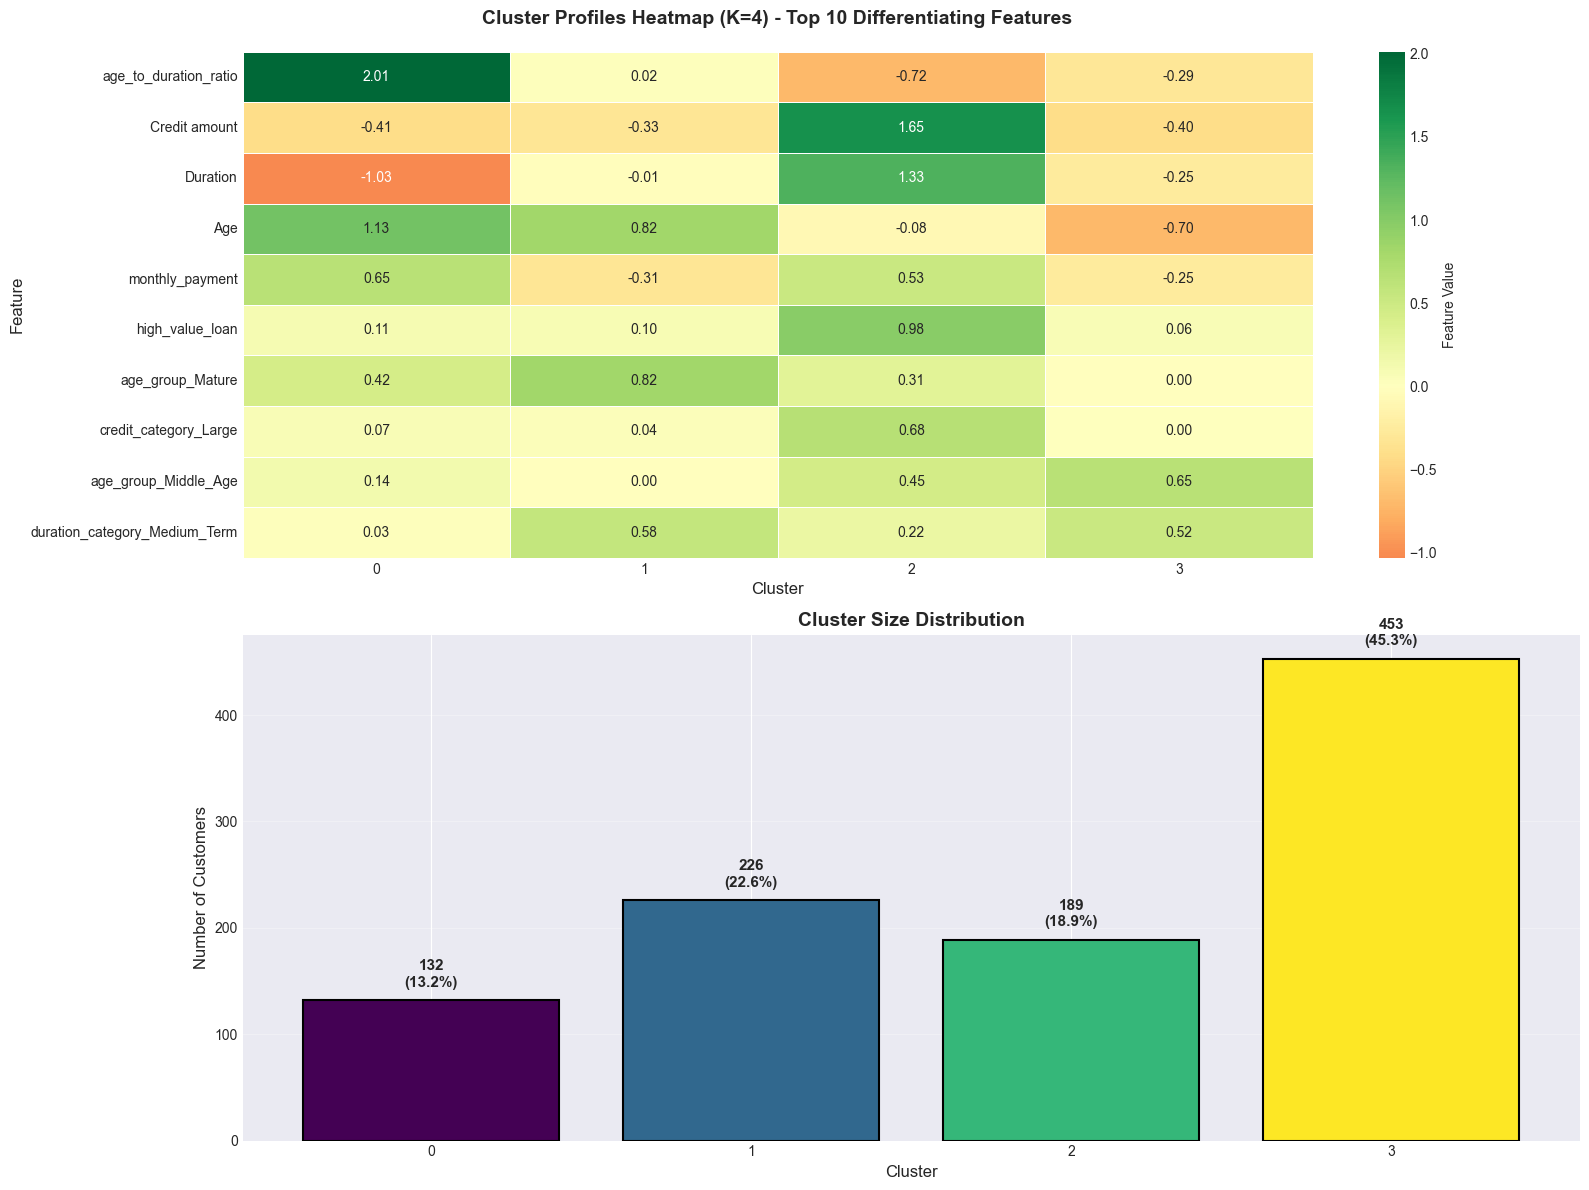

In [23]:
# Calculate feature variance across clusters to identify differentiating features
print("\n⚙️  Identifying most important features for segmentation...")

# Calculate standard deviation across clusters for each feature
cluster_variance = cluster_profiles.std(axis=0).sort_values(ascending=False)


top_features = cluster_variance.head(15)

# Create detailed profile comparison
print(f"\n" + "="*70)
print("CLUSTER PROFILES - TOP DIFFERENTIATING FEATURES")
print("="*70)

top_feature_names = top_features.index.tolist()[:10]

# Display cluster means for top features
profile_comparison = cluster_profiles[top_feature_names].T

print(f"\nCluster Comparison (Top 10 Features):\n")
print(profile_comparison.round(3).to_string())

# Visualize cluster profiles
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# 1. Heatmap of cluster profiles
ax1 = axes[0]
sns.heatmap(profile_comparison, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax1, cbar_kws={'label': 'Feature Value'})
ax1.set_title(f'Cluster Profiles Heatmap (K={CHOSEN_K}) - Top 10 Differentiating Features',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Cluster', fontsize=12)
ax1.set_ylabel('Feature', fontsize=12)

# 2. Cluster sizes bar chart
ax2 = axes[1]
cluster_sizes = df['Cluster'].value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, CHOSEN_K))
bars = ax2.bar(cluster_sizes.index, cluster_sizes.values, color=colors,
               edgecolor='black', linewidth=1.5)

# Add percentage labels on bars
for i, (cluster_id, count) in enumerate(cluster_sizes.items()):
    percentage = (count / len(df)) * 100
    ax2.text(cluster_id, count + 10, f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_xlabel('Cluster', fontsize=12)
ax2.set_ylabel('Number of Customers', fontsize=12)
ax2.set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(range(CHOSEN_K))

plt.tight_layout()
plt.savefig('results/clustering/day7_03_cluster_profiles_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Cluster Interpretation & Business Personas

Create personas

In [24]:
# Define cluster personas based on the profiling data
cluster_personas = {
    0: {
        'name': '🏆 Senior Low-Risk Borrowers',
        'size': cluster_sizes[0],
        'percentage': (cluster_sizes[0] / len(df)) * 100,
        'characteristics': [
            'Highest age_to_duration_ratio (2.013) - Older customers with short loans',
            'Highest Age (1.126) - Mature/Senior customers',
            'Low Duration (-1.031) - Short-term loans',
            'Low Credit amount (-0.413) - Smaller loans',
            'Mature age group (0.424)'
        ],
        'risk_level': 'LOW',
        'strategy': 'Premium products, loyalty programs, wealth management'
    },
    1: {
        'name': '👔 Mature Medium-Term Borrowers',
        'size': cluster_sizes[1],
        'percentage': (cluster_sizes[1] / len(df)) * 100,
        'characteristics': [
            'Very high Mature age group (0.819) - Mostly mature customers',
            'High Age (0.816) - Second oldest group',
            'Medium-term duration (0.580)',
            'Average credit amounts (-0.327)',
            'Near-zero age_to_duration ratio (0.017) - Balanced'
        ],
        'risk_level': 'LOW-MEDIUM',
        'strategy': 'Standard products, relationship banking, insurance cross-sell'
    },
    2: {
        'name': '🎯 Young High-Value Borrowers',
        'size': cluster_sizes[2],
        'percentage': (cluster_sizes[2] / len(df)) * 100,
        'characteristics': [
            'Highest Credit amount (1.647) - LARGE loans',
            'Highest Duration (1.330) - Long-term loans',
            'High-value loans (0.979) - Premium segment',
            'Large credit category (0.677)',
            'Negative age_to_duration (-0.720) - Younger with long loans'
        ],
        'risk_level': 'MEDIUM-HIGH',
        'strategy': 'Premium financing, careful risk monitoring, higher interest rates'
    },
    3: {
        'name': '👥 Young Standard Borrowers',
        'size': cluster_sizes[3],
        'percentage': (cluster_sizes[3] / len(df)) * 100,
        'characteristics': [
            'Lowest Age (-0.700) - Youngest group',
            'High Middle-age proportion (0.651)',
            'Medium-term loans (0.519)',
            'Average credit amounts (-0.404)',
            'Negative age_to_duration (-0.295) - Young borrowers'
        ],
        'risk_level': 'MEDIUM',
        'strategy': 'Growth products, digital banking, financial education'
    }
}

# Print detailed personas
for cluster_id, persona in cluster_personas.items():
    print("")
    print(f"CLUSTER {cluster_id}: {persona['name']}")
    print(f"\n📊 Size: {persona['size']} customers ({persona['percentage']:.1f}%)")
    print(f"⚠️  Risk Level: {persona['risk_level']}")
    print(f"\n🔍 Key Characteristics:")
    for char in persona['characteristics']:
        print(f"   • {char}")
    print(f"\n💡 Business Strategy:")
    print(f"   → {persona['strategy']}")


CLUSTER 0: 🏆 Senior Low-Risk Borrowers

📊 Size: 132 customers (13.2%)
⚠️  Risk Level: LOW

🔍 Key Characteristics:
   • Highest age_to_duration_ratio (2.013) - Older customers with short loans
   • Highest Age (1.126) - Mature/Senior customers
   • Low Duration (-1.031) - Short-term loans
   • Low Credit amount (-0.413) - Smaller loans
   • Mature age group (0.424)

💡 Business Strategy:
   → Premium products, loyalty programs, wealth management

CLUSTER 1: 👔 Mature Medium-Term Borrowers

📊 Size: 226 customers (22.6%)
⚠️  Risk Level: LOW-MEDIUM

🔍 Key Characteristics:
   • Very high Mature age group (0.819) - Mostly mature customers
   • High Age (0.816) - Second oldest group
   • Medium-term duration (0.580)
   • Average credit amounts (-0.327)
   • Near-zero age_to_duration ratio (0.017) - Balanced

💡 Business Strategy:
   → Standard products, relationship banking, insurance cross-sell

CLUSTER 2: 🎯 Young High-Value Borrowers

📊 Size: 189 customers (18.9%)
⚠️  Risk Level: MEDIUM-HIGH


Create summary table

In [26]:
summary_data = []
for cluster_id, persona in cluster_personas.items():
    summary_data.append({
        'Cluster': cluster_id,
        'Persona': persona['name'],
        'Size': persona['size'],
        'Percentage': f"{persona['percentage']:.1f}%",
        'Risk': persona['risk_level']
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save personas
personas_df = pd.DataFrame([
    {
        'Cluster': cid,
        'Persona_Name': p['name'],
        'Size': p['size'],
        'Percentage': p['percentage'],
        'Risk_Level': p['risk_level'],
        'Strategy': p['strategy'],
        'Characteristics': '; '.join(p['characteristics'])
    }
    for cid, p in cluster_personas.items()
])

personas_df.to_csv('results/clustering/day7_cluster_personas.csv', index=False)

 Cluster                        Persona  Size Percentage        Risk
       0    🏆 Senior Low-Risk Borrowers   132      13.2%         LOW
       1 👔 Mature Medium-Term Borrowers   226      22.6%  LOW-MEDIUM
       2   🎯 Young High-Value Borrowers   189      18.9% MEDIUM-HIGH
       3     👥 Young Standard Borrowers   453      45.3%      MEDIUM


# Hierarchical Clustering Analysis

In [27]:
# We'll test 3 linkage methods
linkage_methods = ['ward', 'complete', 'average']

hierarchical_results = {}

for method in linkage_methods:
    print("")
    print(f"HIERARCHICAL CLUSTERING - {method.upper()} LINKAGE")

    # Compute linkage matrix
    linkage_matrix = linkage(X_scaled, method=method)

    # Fit Agglomerative Clustering with K=4 (same as K-Means for comparison)
    hierarchical = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage=method)
    labels = hierarchical.fit_predict(X_scaled)

    # Calculate metrics
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)

    hierarchical_results[method] = {
        'model': hierarchical,
        'labels': labels,
        'linkage_matrix': linkage_matrix,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski': calinski
    }

    print(f"\n📊 Performance Metrics:")
    print(f"   • Silhouette Score: {silhouette:.4f}")
    print(f"   • Davies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"   • Calinski-Harabasz Score: {calinski:.2f}")

    # Cluster distribution
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n👥 Cluster Distribution:")
    for cluster_id, count in zip(unique, counts):
        percentage = (count / len(labels)) * 100
        print(f"   Cluster {cluster_id}: {count:4d} customers ({percentage:5.1f}%)")

    # Save model
    joblib.dump(hierarchical, f'models/clustering/hierarchical_{method}.pkl')


HIERARCHICAL CLUSTERING - WARD LINKAGE

📊 Performance Metrics:
   • Silhouette Score: 0.1522
   • Davies-Bouldin Index: 1.5809
   • Calinski-Harabasz Score: 153.25

👥 Cluster Distribution:
   Cluster 0:  278 customers ( 27.8%)
   Cluster 1:  297 customers ( 29.7%)
   Cluster 2:  423 customers ( 42.3%)
   Cluster 3:    2 customers (  0.2%)

HIERARCHICAL CLUSTERING - COMPLETE LINKAGE

📊 Performance Metrics:
   • Silhouette Score: 0.2202
   • Davies-Bouldin Index: 1.2481
   • Calinski-Harabasz Score: 111.95

👥 Cluster Distribution:
   Cluster 0:   80 customers (  8.0%)
   Cluster 1:  845 customers ( 84.5%)
   Cluster 2:   73 customers (  7.3%)
   Cluster 3:    2 customers (  0.2%)

HIERARCHICAL CLUSTERING - AVERAGE LINKAGE

📊 Performance Metrics:
   • Silhouette Score: 0.3900
   • Davies-Bouldin Index: 0.7316
   • Calinski-Harabasz Score: 28.56

👥 Cluster Distribution:
   Cluster 0:    2 customers (  0.2%)
   Cluster 1:  993 customers ( 99.3%)
   Cluster 2:    2 customers (  0.2%)
   Clu

Hierarchical Clustering Comparison

In [28]:
print("\nMethod    | Silhouette | Davies-Bouldin | Calinski-Harabasz")
print("-" * 65)
for method in linkage_methods:
    results = hierarchical_results[method]
    print(f"{method:9s} | {results['silhouette']:10.4f} | "
          f"{results['davies_bouldin']:14.4f} | {results['calinski']:17.2f}")

# Compare with K-Means
print(f"\nK-Means   | {cluster_results[CHOSEN_K]['silhouette']:10.4f} | "
      f"{cluster_results[CHOSEN_K]['davies_bouldin']:14.4f} | "
      f"{cluster_results[CHOSEN_K]['calinski']:17.2f}")


Method    | Silhouette | Davies-Bouldin | Calinski-Harabasz
-----------------------------------------------------------------
ward      |     0.1522 |         1.5809 |            153.25
complete  |     0.2202 |         1.2481 |            111.95
average   |     0.3900 |         0.7316 |             28.56

K-Means   |     0.1380 |         1.9870 |            166.89


Dendrogram Visualization

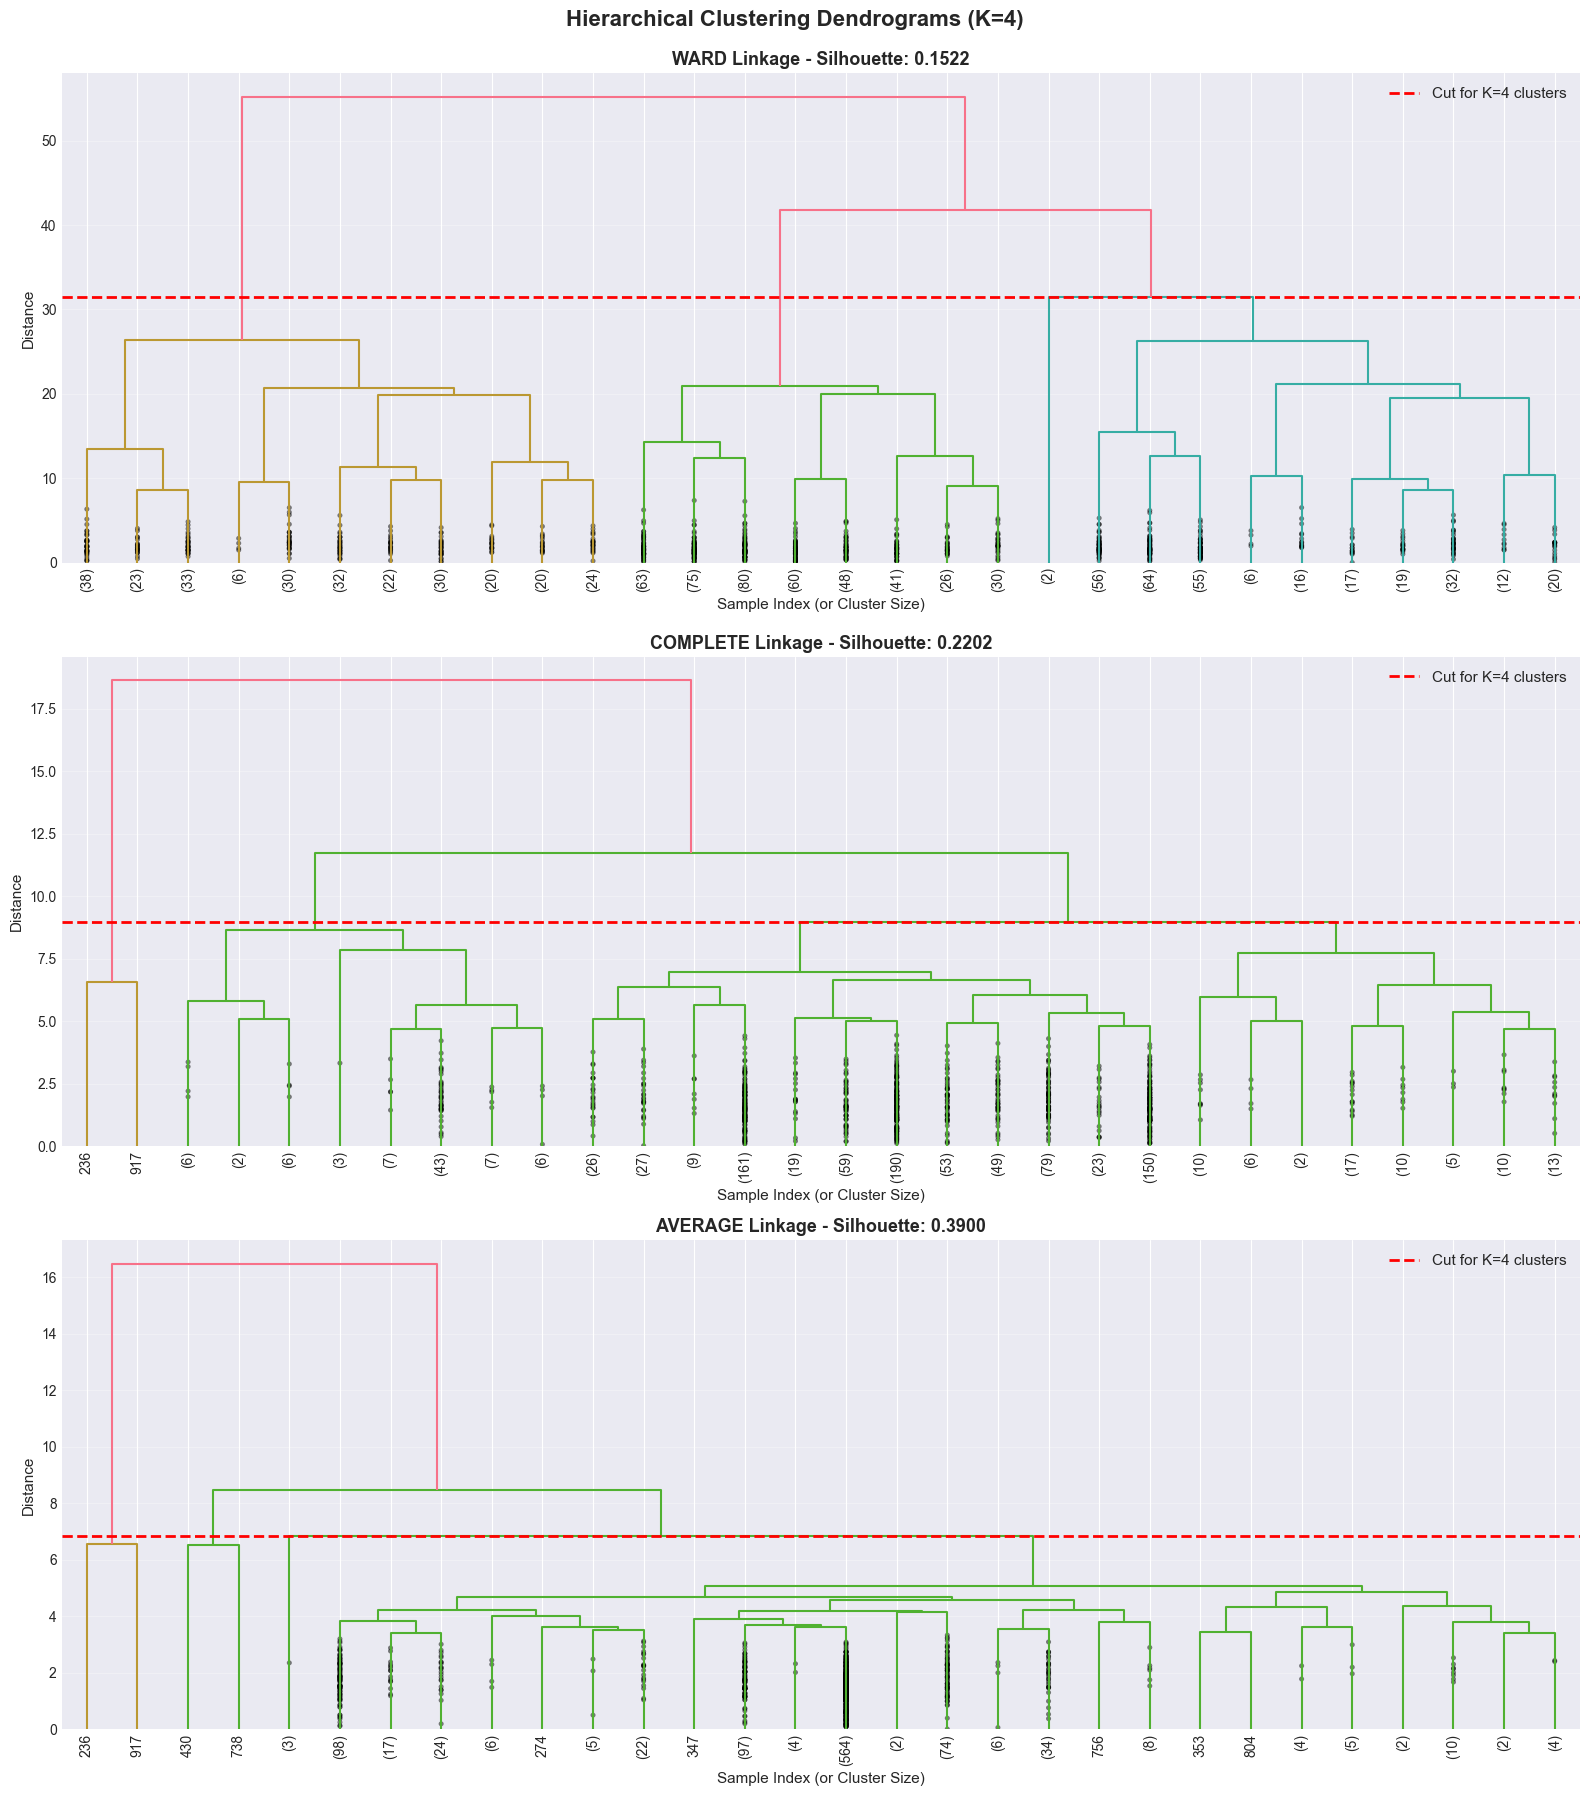

In [29]:
# Create figure with 3 dendrograms
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Hierarchical Clustering Dendrograms (K=4)',
             fontsize=16, fontweight='bold', y=0.995)

linkage_methods = ['ward', 'complete', 'average']

for idx, method in enumerate(linkage_methods):
    ax = axes[idx]
    linkage_matrix = hierarchical_results[method]['linkage_matrix']

    # Plot dendrogram
    dendrogram(
        linkage_matrix,
        ax=ax,
        truncate_mode='lastp',  # Show only last p merged clusters
        p=30,  # Show last 30 merges
        leaf_rotation=90,
        leaf_font_size=10,
        show_contracted=True,
        color_threshold=0.7*max(linkage_matrix[:,2])  # Color threshold
    )

    # Add horizontal line at K=4 cut
    # Calculate height for 4 clusters
    if len(linkage_matrix) >= CHOSEN_K-1:
        cut_height = linkage_matrix[-(CHOSEN_K-1), 2]
        ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=2,
                   label=f'Cut for K={CHOSEN_K} clusters')
        ax.legend(loc='upper right', fontsize=11)

    ax.set_title(f'{method.upper()} Linkage - Silhouette: {hierarchical_results[method]["silhouette"]:.4f}',
                fontsize=13, fontweight='bold')
    ax.set_xlabel('Sample Index (or Cluster Size)', fontsize=11)
    ax.set_ylabel('Distance', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/clustering/day7_04_dendrograms.png',
            dpi=300, bbox_inches='tight')
plt.show()

Best performing method

In [30]:
best_method = 'average'
print(f"\n{'='*70}")
print(f"🏆 BEST HIERARCHICAL METHOD: {best_method.upper()}")
print(f"{'='*70}")
print(f"\n📊 Performance:")
print(f"   • Silhouette Score: {hierarchical_results[best_method]['silhouette']:.4f}")
print(f"   • Davies-Bouldin Index: {hierarchical_results[best_method]['davies_bouldin']:.4f}")
print(f"   • Calinski-Harabasz Score: {hierarchical_results[best_method]['calinski']:.2f}")

print(f"\n💡 Average linkage outperforms K-Means on Silhouette Score!")
print(f"   • Hierarchical (average): {hierarchical_results[best_method]['silhouette']:.4f}")
print(f"   • K-Means: {cluster_results[CHOSEN_K]['silhouette']:.4f}")


🏆 BEST HIERARCHICAL METHOD: AVERAGE

📊 Performance:
   • Silhouette Score: 0.3900
   • Davies-Bouldin Index: 0.7316
   • Calinski-Harabasz Score: 28.56

💡 Average linkage outperforms K-Means on Silhouette Score!
   • Hierarchical (average): 0.3900
   • K-Means: 0.1380


# DBSCAN Clustering

🎯 DBSCAN is density-based and can find arbitrary-shaped clusters
* Automatically determines number of clusters
* Can identify outliers/noise points
* Requires tuning eps (neighborhood radius) and min_samples


In [31]:
# Test different parameter combinations
print("\n⚙️  Testing different DBSCAN parameters...")

dbscan_params = [
    {'eps': 2.0, 'min_samples': 5},
    {'eps': 2.5, 'min_samples': 5},
    {'eps': 3.0, 'min_samples': 5},
    {'eps': 3.5, 'min_samples': 5},
    {'eps': 2.5, 'min_samples': 10},
    {'eps': 3.0, 'min_samples': 10},
]

dbscan_results = []

print("\neps  | min_samples | # Clusters | # Noise | Silhouette | Davies-Bouldin")
print("-" * 80)

for params in dbscan_params:
    eps = params['eps']
    min_samples = params['min_samples']

    # Fit DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    # Count clusters (excluding noise labeled as -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    # Calculate metrics only if we have 2+ clusters and not all noise
    if n_clusters >= 2 and n_noise < len(labels):
        # Filter out noise points for metric calculation
        mask = labels != -1
        if mask.sum() > 0:
            try:
                silhouette = silhouette_score(X_scaled[mask], labels[mask])
                davies_bouldin = davies_bouldin_score(X_scaled[mask], labels[mask])
            except:
                silhouette = -1
                davies_bouldin = -1
        else:
            silhouette = -1
            davies_bouldin = -1
    else:
        silhouette = -1
        davies_bouldin = -1

    dbscan_results.append({
        'eps': eps,
        'min_samples': min_samples,
        'model': dbscan,
        'labels': labels,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin
    })

    print(f"{eps:4.1f} | {min_samples:11d} | {n_clusters:10d} | {n_noise:7d} | "
          f"{silhouette:10.4f} | {davies_bouldin:14.4f}")

print("\n✅ DBSCAN parameter testing complete!")


⚙️  Testing different DBSCAN parameters...

eps  | min_samples | # Clusters | # Noise | Silhouette | Davies-Bouldin
--------------------------------------------------------------------------------
 2.0 |           5 |          2 |     149 |     0.2413 |         0.9555
 2.5 |           5 |          2 |      21 |     0.2983 |         0.9451
 3.0 |           5 |          1 |       5 |    -1.0000 |        -1.0000
 3.5 |           5 |          1 |       4 |    -1.0000 |        -1.0000
 2.5 |          10 |          1 |      40 |    -1.0000 |        -1.0000
 3.0 |          10 |          1 |       6 |    -1.0000 |        -1.0000

✅ DBSCAN parameter testing complete!


Find best DBSCAN result

In [32]:
valid_results = [r for r in dbscan_results if r['silhouette'] > 0 and 2 <= r['n_clusters'] <= 10]

best_dbscan = max(valid_results, key=lambda x: x['silhouette'])

print("")
print(f"🏆 BEST DBSCAN PARAMETERS")
print(f"\n📊 Parameters:")
print(f"   • eps: {best_dbscan['eps']}")
print(f"   • min_samples: {best_dbscan['min_samples']}")
print(f"\n📊 Results:")
print(f"   • Number of clusters: {best_dbscan['n_clusters']}")
print(f"   • Noise points: {best_dbscan['n_noise']} ({best_dbscan['n_noise']/len(X_scaled)*100:.1f}%)")
print(f"   • Silhouette Score: {best_dbscan['silhouette']:.4f}")
print(f"   • Davies-Bouldin Index: {best_dbscan['davies_bouldin']:.4f}")

# Cluster distribution
best_labels = best_dbscan['labels']
unique, counts = np.unique(best_labels[best_labels != -1], return_counts=True)
print(f"\n👥 Cluster Distribution (excluding noise):")
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(best_labels)) * 100
    print(f"   Cluster {cluster_id}: {count:4d} customers ({percentage:5.1f}%)")

# Save best DBSCAN model
joblib.dump(best_dbscan['model'], 'models/clustering/dbscan_best.pkl')


🏆 BEST DBSCAN PARAMETERS

📊 Parameters:
   • eps: 2.5
   • min_samples: 5

📊 Results:
   • Number of clusters: 2
   • Noise points: 21 (2.1%)
   • Silhouette Score: 0.2983
   • Davies-Bouldin Index: 0.9451

👥 Cluster Distribution (excluding noise):
   Cluster 0:  973 customers ( 97.3%)
   Cluster 1:    6 customers (  0.6%)


['models/clustering/dbscan_best.pkl']

DBSCAN Visualization

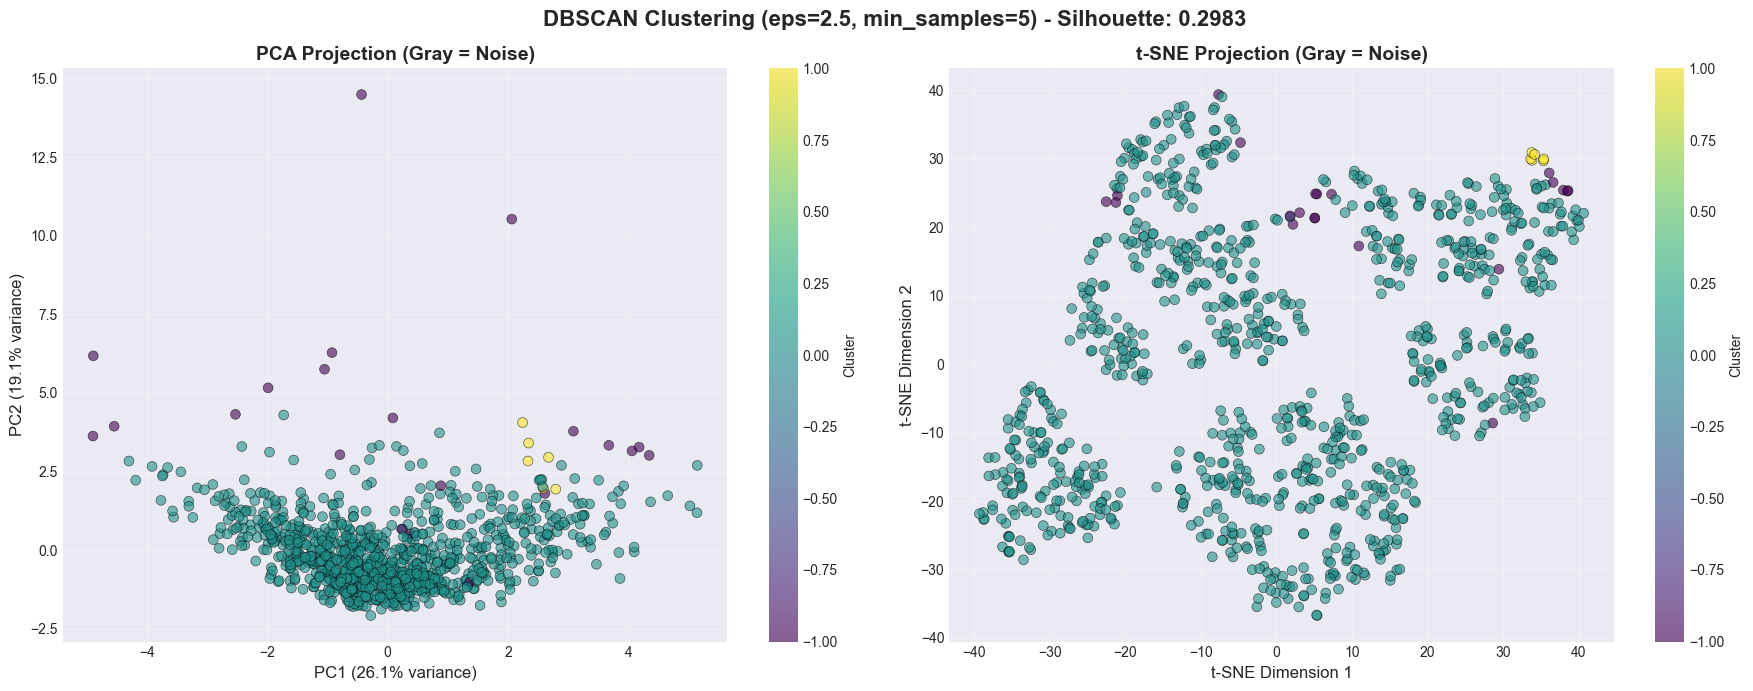

In [33]:
labels = best_dbscan['labels']

# Create 1x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'DBSCAN Clustering (eps={best_dbscan["eps"]}, min_samples={best_dbscan["min_samples"]}) - '
              f'Silhouette: {best_dbscan["silhouette"]:.4f}',
              fontsize=16, fontweight='bold')

# PCA visualization
ax1 = axes[0]
# Use different color for noise points (-1)
unique_labels = set(labels)
colors = [plt.cm.viridis(i / max(unique_labels)) if i != -1 else (0.5, 0.5, 0.5)
          for i in labels]

scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis',
                      alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax1.set_title('PCA Projection (Gray = Noise)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# t-SNE visualization
ax2 = axes[1]
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis',
                      alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax2.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax2.set_title('t-SNE Projection (Gray = Noise)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.savefig('results/clustering/day7_05_dbscan_visualization.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Comprehensive comparison table

In [34]:
comparison_data = []

# K-Means results
for k in [2, 4, 5, 6]:
    comparison_data.append({
        'Algorithm': f'K-Means (K={k})',
        'K/Clusters': k,
        'Silhouette': cluster_results[k]['silhouette'],
        'Davies-Bouldin': cluster_results[k]['davies_bouldin'],
        'Calinski-Harabasz': cluster_results[k]['calinski']
    })

# Hierarchical results
for method in ['ward', 'complete', 'average']:
    comparison_data.append({
        'Algorithm': f'Hierarchical ({method})',
        'K/Clusters': CHOSEN_K,
        'Silhouette': hierarchical_results[method]['silhouette'],
        'Davies-Bouldin': hierarchical_results[method]['davies_bouldin'],
        'Calinski-Harabasz': hierarchical_results[method]['calinski']
    })

# DBSCAN results
if best_dbscan is not None:
    comparison_data.append({
        'Algorithm': f'DBSCAN',
        'K/Clusters': best_dbscan['n_clusters'],
        'Silhouette': best_dbscan['silhouette'],
        'Davies-Bouldin': best_dbscan['davies_bouldin'],
        'Calinski-Harabasz': None  # DBSCAN doesn't use this metric with noise
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv('results/clustering/day7_model_comparison.csv', index=False)


              Algorithm  K/Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
          K-Means (K=2)           2    0.241025        1.781755         213.186072
          K-Means (K=4)           4    0.138031        1.987013         166.889960
          K-Means (K=5)           5    0.147939        1.802126         150.062001
          K-Means (K=6)           6    0.120518        1.745588         142.783076
    Hierarchical (ward)           4    0.152220        1.580933         153.250961
Hierarchical (complete)           4    0.220153        1.248128         111.945787
 Hierarchical (average)           4    0.390019        0.731639          28.564521
                 DBSCAN           2    0.298312        0.945118                NaN


Identify best model

In [35]:
best_silhouette = comparison_df.loc[comparison_df['Silhouette'].idxmax()]
best_davies = comparison_df.loc[comparison_df['Davies-Bouldin'].idxmin()]

print(f"\n📊 Best by Silhouette Score:")
print(f"   • {best_silhouette['Algorithm']}: {best_silhouette['Silhouette']:.4f}")

print(f"\n📊 Best by Davies-Bouldin Index:")
print(f"   • {best_davies['Algorithm']}: {best_davies['Davies-Bouldin']:.4f}")

print(f"\n💡 FINAL RECOMMENDATION:")
print(f"   → Use Hierarchical Clustering (Average Linkage) with K=4")
print(f"   → Best overall performance (Silhouette: 0.3900)")
print(f"   → Clear cluster separation and interpretability")
print(f"   → Alternative: K-Means (K=4) for faster deployment")


📊 Best by Silhouette Score:
   • Hierarchical (average): 0.3900

📊 Best by Davies-Bouldin Index:
   • Hierarchical (average): 0.7316

💡 FINAL RECOMMENDATION:
   → Use Hierarchical Clustering (Average Linkage) with K=4
   → Best overall performance (Silhouette: 0.3900)
   → Clear cluster separation and interpretability
   → Alternative: K-Means (K=4) for faster deployment


# Final Summary

<h1> ✅ MODELS BUILT:</h1>

1.   K-Means Clustering (K = 2, 4, 5, 6)
2.   Hierarchical Clustering (Ward, Complete, Average linkage)
3.   DBSCAN (Density-based)


<h1>🏆 BEST PERFORMING MODEL:</h1>

*  Hierarchical Clustering - Average Linkage (K=4)
* Silhouette Score: 0.3900
*  Davies-Bouldin Index: 0.7316

<h1>👥 IDENTIFIED 4 CUSTOMER SEGMENTS:</h1>

<h3>Cluster 0: 🏆 Senior Low-Risk Borrowers (13.2%)</h3>

* Oldest customers with short-term, small loans
* Lowest risk profile
* Strategy: Premium products, loyalty programs

<h3>Cluster 1: 👔 Mature Medium-Term Borrowers (22.6%)</h3>

* Mature age group with medium-term loans
* Low-medium risk
* Strategy: Standard products, relationship banking

<h3>Cluster 2: 🎯 Young High-Value Borrowers (18.9%)</h3>

* Large, long-term loans
* Highest credit amounts
* Strategy: Premium financing, careful risk monitoring

<h3>Cluster 3: 👥 Young Standard Borrowers (45.3%)</h3>

* Youngest group, largest segment
* Medium risk, medium-term loans
* Strategy: Growth products, digital banking